# BI-LSTM Model Evaluation & Visualization

**Goal**: Visualize how the trained model detects arcs vs lines

**Model Performance**:
- Accuracy: 99.72%
- AUC: 0.9999
- Precision: 99.56%
- Recall: 100%


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
import pickle
import sys
sys.path.append('../classification')
from preprocessing import TrajectoryPreprocessor

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 10)


## 1. Load Trained Model & Data


In [5]:
# Load the trained model
model_path = '../../models/bilstm_classifier_20251123_130140.keras'
model = keras.models.load_model(model_path)

# Load preprocessor
preprocessor_path = '../../models/preprocessor.pkl'
with open(preprocessor_path, 'rb') as f:
    preprocessor = pickle.load(f)

# Load test data
X_test = np.load('../../data/processed/X_test.npy')
y_test = np.load('../../data/processed/y_test.npy')
print(f"Test data loaded: {X_test.shape}")
print(f"  - Test samples: {len(X_test)}")
print(f"  - Label 0 (Arc): {np.sum(y_test == 0)}")
print(f"  - Label 1 (Line): {np.sum(y_test == 1)}")


Test data loaded: (7247, 150, 13)
  - Test samples: 7247
  - Label 0 (Arc): 2752
  - Label 1 (Line): 4495


## 2. Make Predictions


In [6]:
# Get predictions
print("Making predictions...")
y_pred_proba = model.predict(X_test, batch_size=64, verbose=1)
y_pred = (y_pred_proba >= 0.5).astype(int).flatten()

# Calculate accuracy
accuracy = np.mean(y_pred == y_test)
print(f"\n✓ Predictions complete!")
print(f"  Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Find correct and incorrect predictions
correct_mask = (y_pred == y_test)
incorrect_mask = ~correct_mask

print(f"\n  Correct predictions: {correct_mask.sum()}")
print(f"  Incorrect predictions: {incorrect_mask.sum()}")


Making predictions...
114/114 ━━━━━━━━━━━━━━━━━━━━ 15s 123ms/step

✓ Predictions complete!
  Accuracy: 0.9967 (99.67%)

  Correct predictions: 7223
  Incorrect predictions: 24


## 3. Confusion Matrix


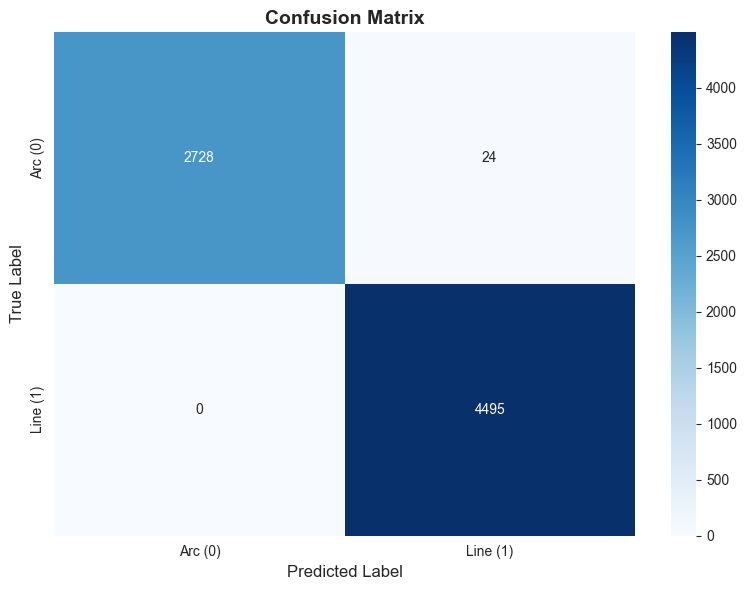


Classification Report:
              precision    recall  f1-score   support

         Arc     1.0000    0.9913    0.9956      2752
        Line     0.9947    1.0000    0.9973      4495

    accuracy                         0.9967      7247
   macro avg     0.9973    0.9956    0.9965      7247
weighted avg     0.9967    0.9967    0.9967      7247



In [7]:
from sklearn.metrics import confusion_matrix, classification_report

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Arc (0)', 'Line (1)'],
            yticklabels=['Arc (0)', 'Line (1)'])
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Classification report
print("\nClassification Report:")
print("="*60)
print(classification_report(y_test, y_pred, 
                           target_names=['Arc', 'Line'],
                           digits=4))


## 4. Prediction Confidence Distribution


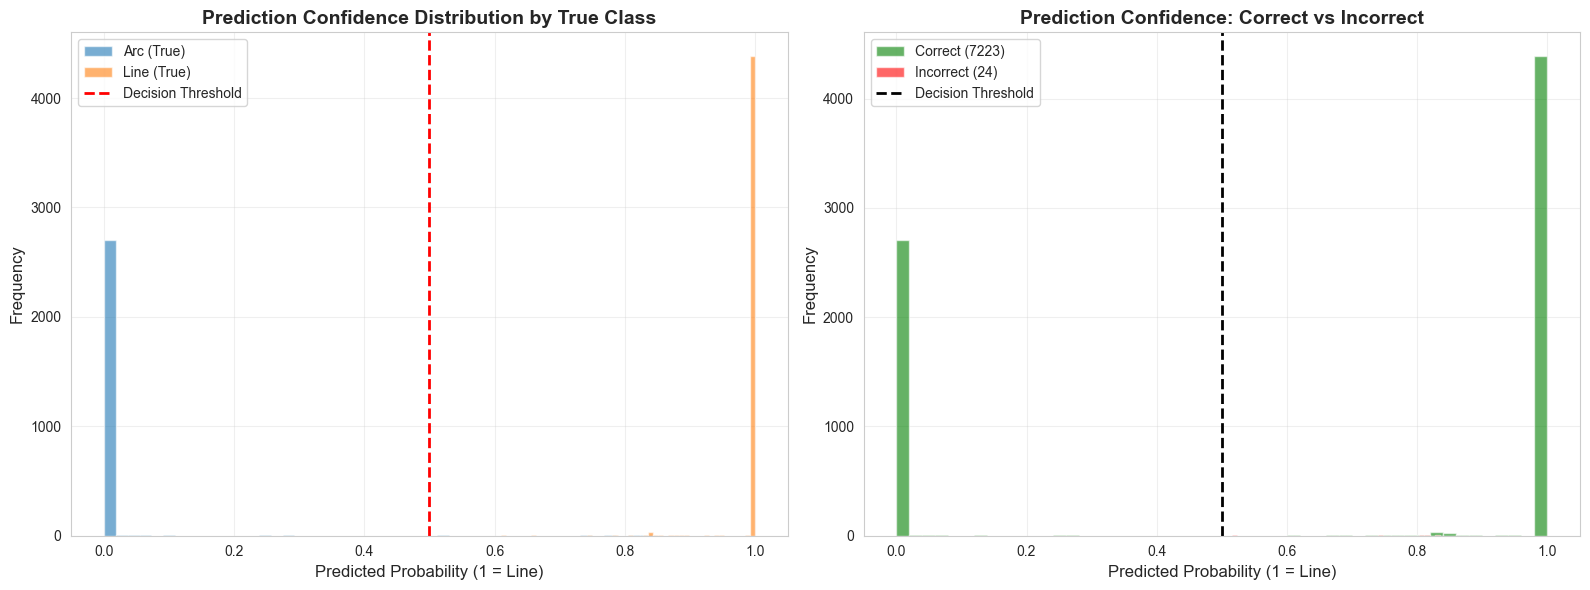

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confidence for each class
for class_label, class_name in [(0, 'Arc'), (1, 'Line')]:
    class_mask = (y_test == class_label)
    class_probas = y_pred_proba[class_mask].flatten()
    
    axes[0].hist(class_probas, bins=50, alpha=0.6, label=f'{class_name} (True)')

axes[0].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Decision Threshold')
axes[0].set_xlabel('Predicted Probability (1 = Line)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Prediction Confidence Distribution by True Class', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Confidence for correct vs incorrect
correct_probas = y_pred_proba[correct_mask].flatten()
incorrect_probas = y_pred_proba[incorrect_mask].flatten()

axes[1].hist(correct_probas, bins=50, alpha=0.6, color='green', label=f'Correct ({len(correct_probas)})')
if len(incorrect_probas) > 0:
    axes[1].hist(incorrect_probas, bins=50, alpha=0.6, color='red', label=f'Incorrect ({len(incorrect_probas)})')
axes[1].axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Decision Threshold')
axes[1].set_xlabel('Predicted Probability (1 = Line)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Prediction Confidence: Correct vs Incorrect', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Visualize Predictions on Actual Trajectories

Let's see how the model classifies real trajectory segments!


Correct Predictions (Random Sample):


/var/folders/_g/nlrpl_cd5mz07kz6t_shzl9w0000gn/T/ipykernel_43402/123718296.py:49: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/Users/bahacelik/Documents/Coding/BI-LSTM-Classification/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


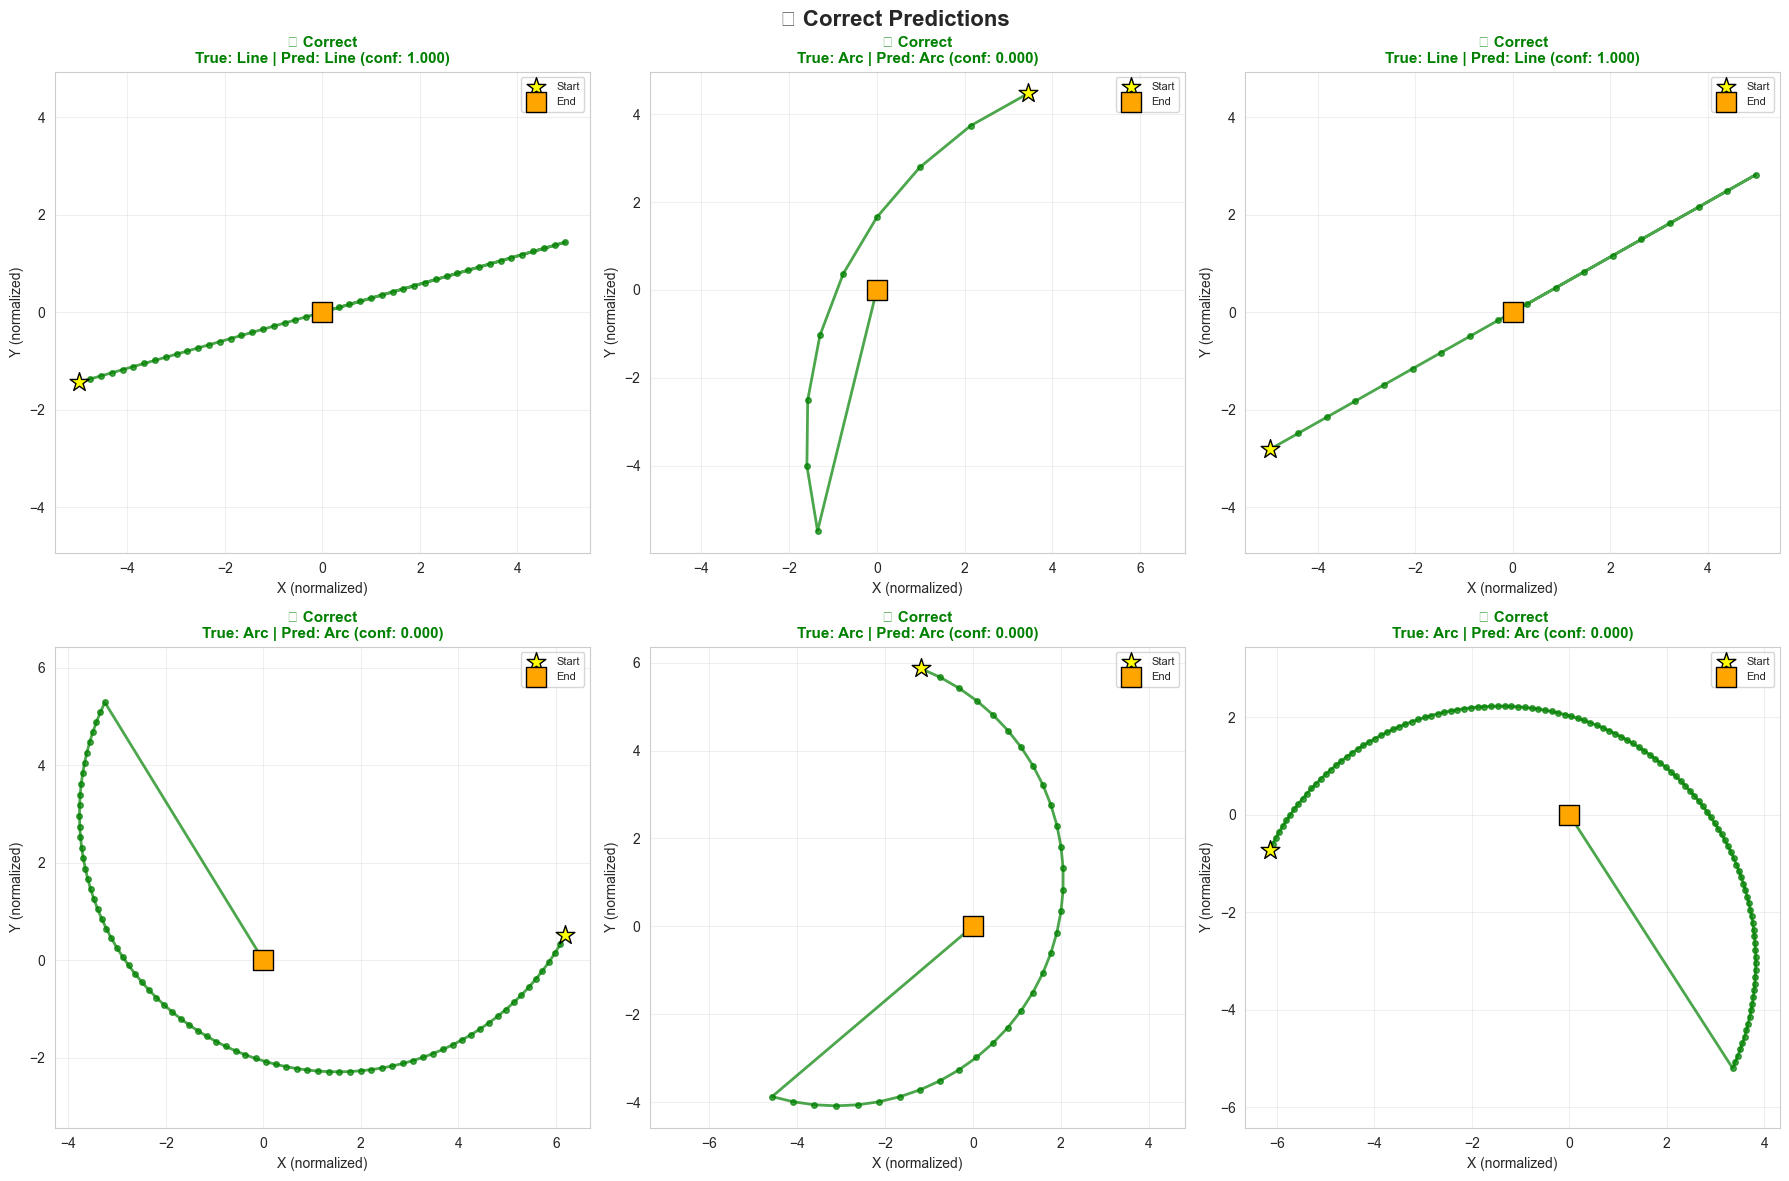

In [9]:
def plot_trajectory_predictions(X, y_true, y_pred, y_proba, indices, title=""):
    """Plot trajectories with predictions."""
    n = len(indices)
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    for i, idx in enumerate(indices[:6]):  # Max 6 plots
        # Extract coordinates (first 2 features are x, y)
        sequence = X[idx, :, :2]  # Shape: (150, 2)
        
        # Remove padding (zeros)
        non_zero_mask = np.any(sequence != 0, axis=1)
        coords = sequence[non_zero_mask]
        
        if len(coords) == 0:
            continue
            
        x, y = coords[:, 0], coords[:, 1]
        
        # True and predicted labels
        true_label = "Arc" if y_true[idx] == 0 else "Line"
        pred_label = "Arc" if y_pred[idx] == 0 else "Line"
        confidence = y_proba[idx][0]
        is_correct = (y_true[idx] == y_pred[idx])
        
        # Color based on correctness
        color = 'green' if is_correct else 'red'
        
        # Plot
        axes[i].plot(x, y, 'o-', linewidth=2, markersize=4, color=color, alpha=0.7)
        axes[i].scatter(x[0], y[0], c='yellow', s=200, marker='*', 
                       edgecolors='black', zorder=10, label='Start')
        axes[i].scatter(x[-1], y[-1], c='orange', s=200, marker='s',
                       edgecolors='black', zorder=10, label='End')
        
        # Title with prediction info
        status = "✓ Correct" if is_correct else "✗ Wrong"
        axes[i].set_title(
            f'{status}\nTrue: {true_label} | Pred: {pred_label} (conf: {confidence:.3f})',
            fontsize=11, fontweight='bold', color=color
        )
        axes[i].set_xlabel('X (normalized)')
        axes[i].set_ylabel('Y (normalized)')
        axes[i].legend(fontsize=8)
        axes[i].grid(True, alpha=0.3)
        axes[i].axis('equal')
    
    fig.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


# Plot some correct predictions
print("Correct Predictions (Random Sample):")
correct_indices = np.where(correct_mask)[0]
random_correct = np.random.choice(correct_indices, min(6, len(correct_indices)), replace=False)
plot_trajectory_predictions(X_test, y_test, y_pred, y_pred_proba, 
                           random_correct, 
                           title="✓ Correct Predictions")



Incorrect Predictions (24 total):


/var/folders/_g/nlrpl_cd5mz07kz6t_shzl9w0000gn/T/ipykernel_43402/123718296.py:49: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.tight_layout()
/Users/bahacelik/Documents/Coding/BI-LSTM-Classification/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


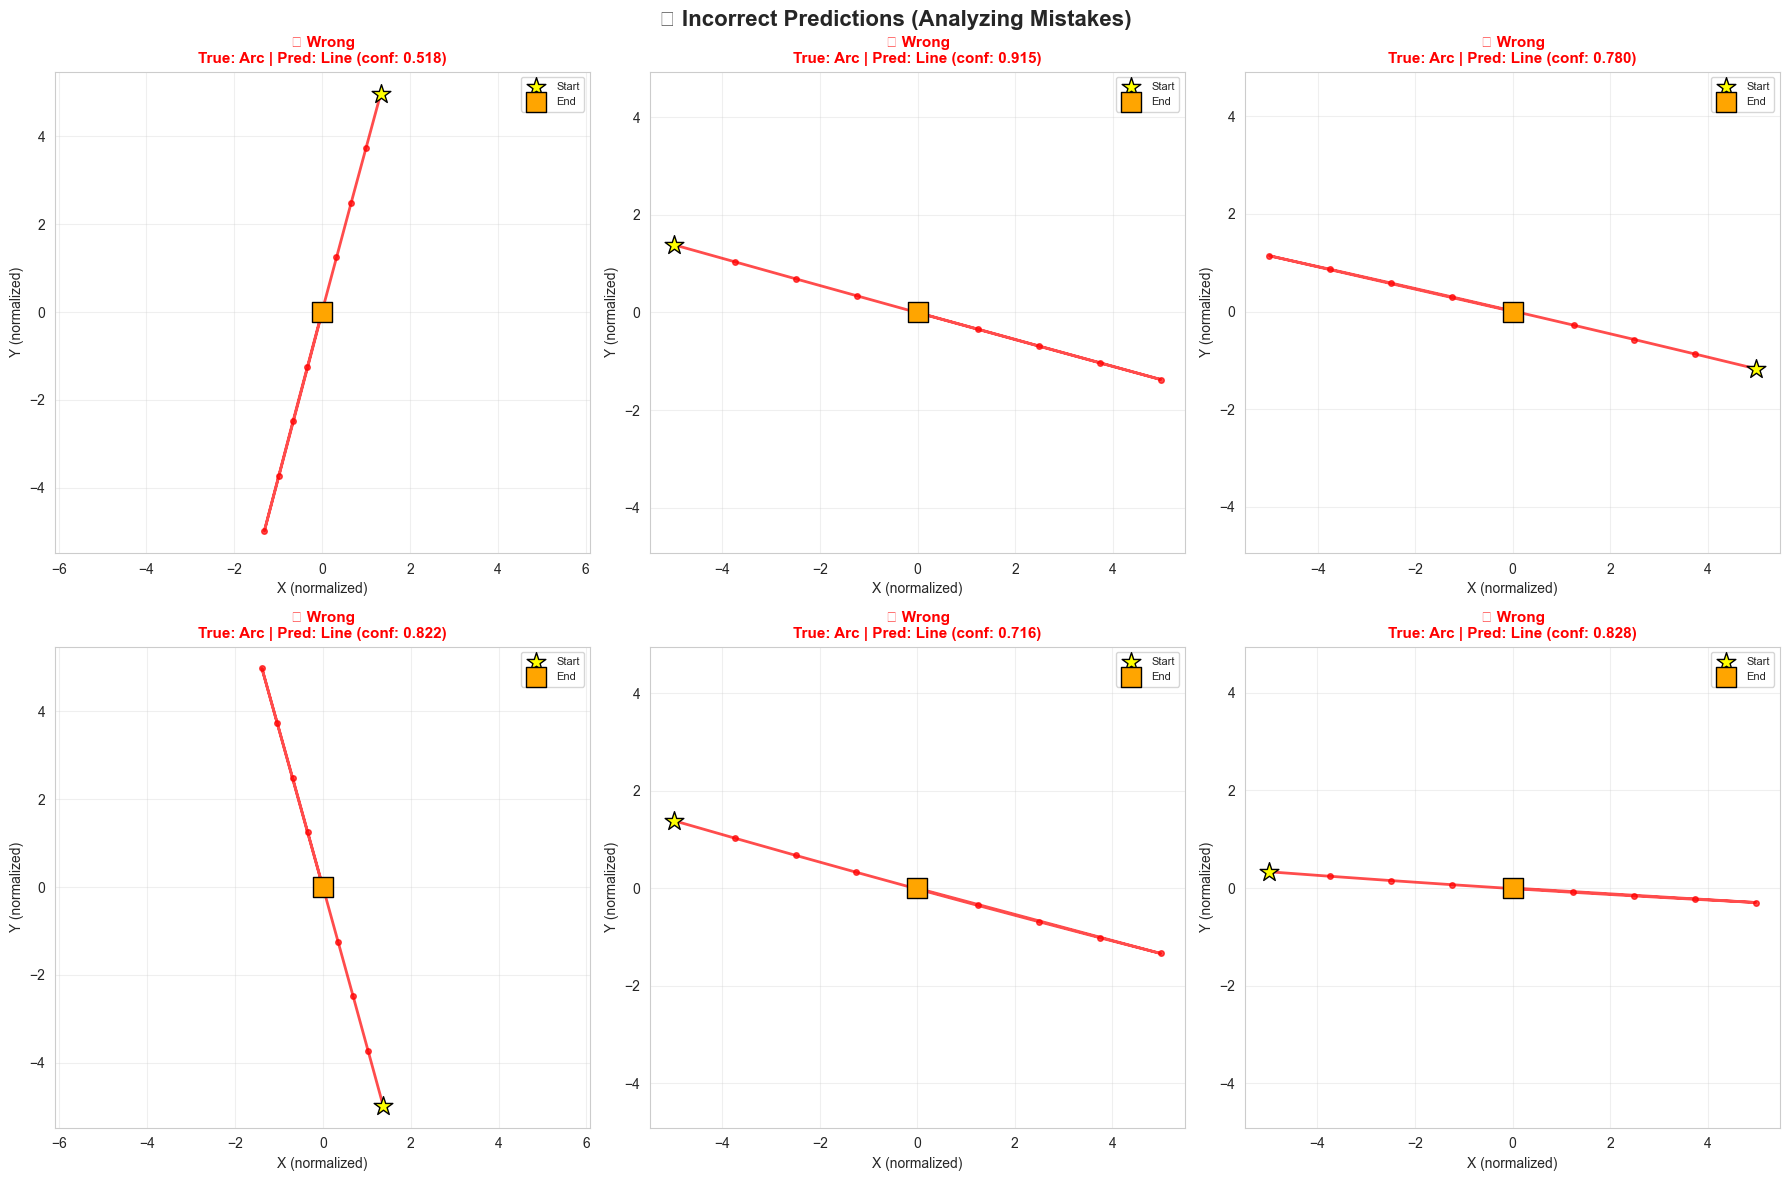

In [10]:
# Plot incorrect predictions (if any)
if incorrect_mask.sum() > 0:
    print(f"\nIncorrect Predictions ({incorrect_mask.sum()} total):")
    incorrect_indices = np.where(incorrect_mask)[0]
    plot_trajectory_predictions(X_test, y_test, y_pred, y_pred_proba, 
                               incorrect_indices, 
                               title="✗ Incorrect Predictions (Analyzing Mistakes)")
else:
    print("\n🎉 No incorrect predictions! Perfect classification!")


## 6. High Confidence vs Low Confidence Predictions


High Confidence Predictions (Very certain):


/var/folders/_g/nlrpl_cd5mz07kz6t_shzl9w0000gn/T/ipykernel_43402/123718296.py:49: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()


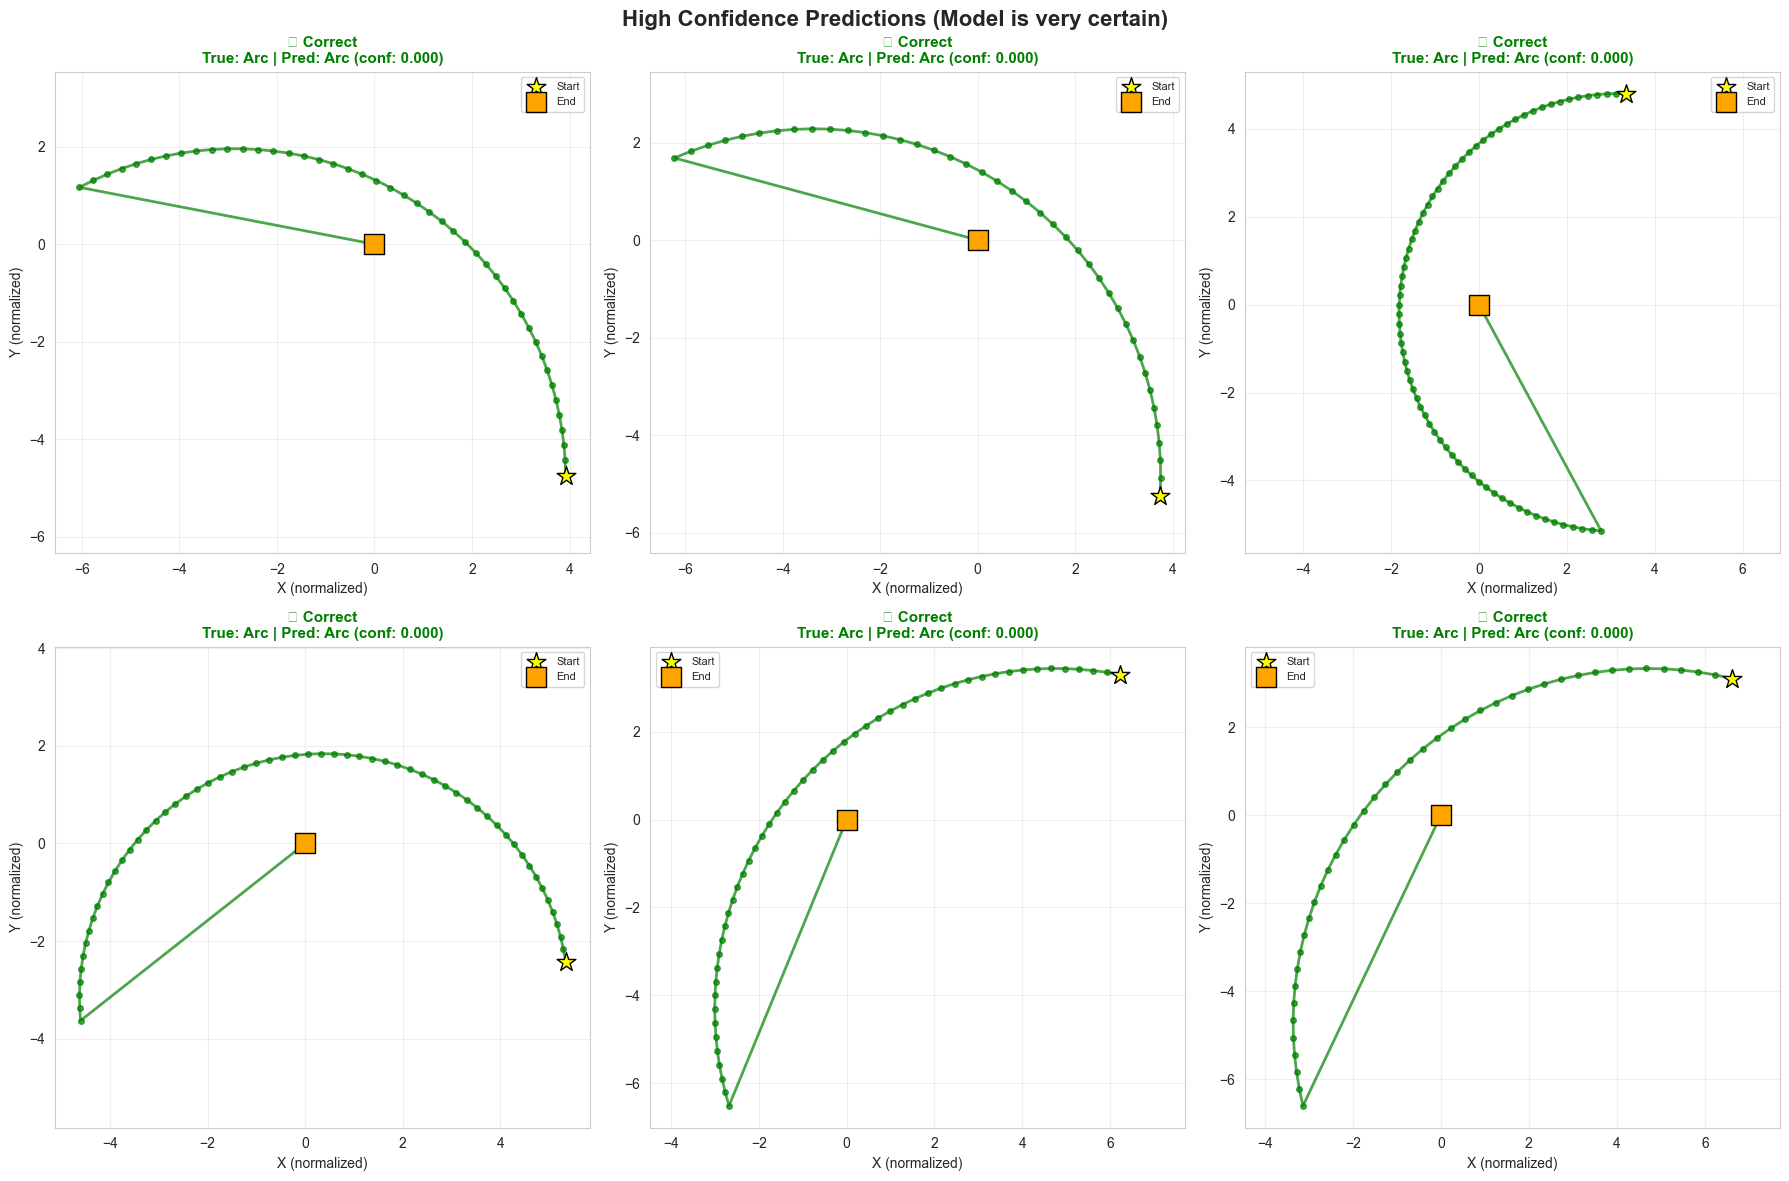


Low Confidence Predictions (Uncertain cases):


/var/folders/_g/nlrpl_cd5mz07kz6t_shzl9w0000gn/T/ipykernel_43402/123718296.py:49: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.tight_layout()


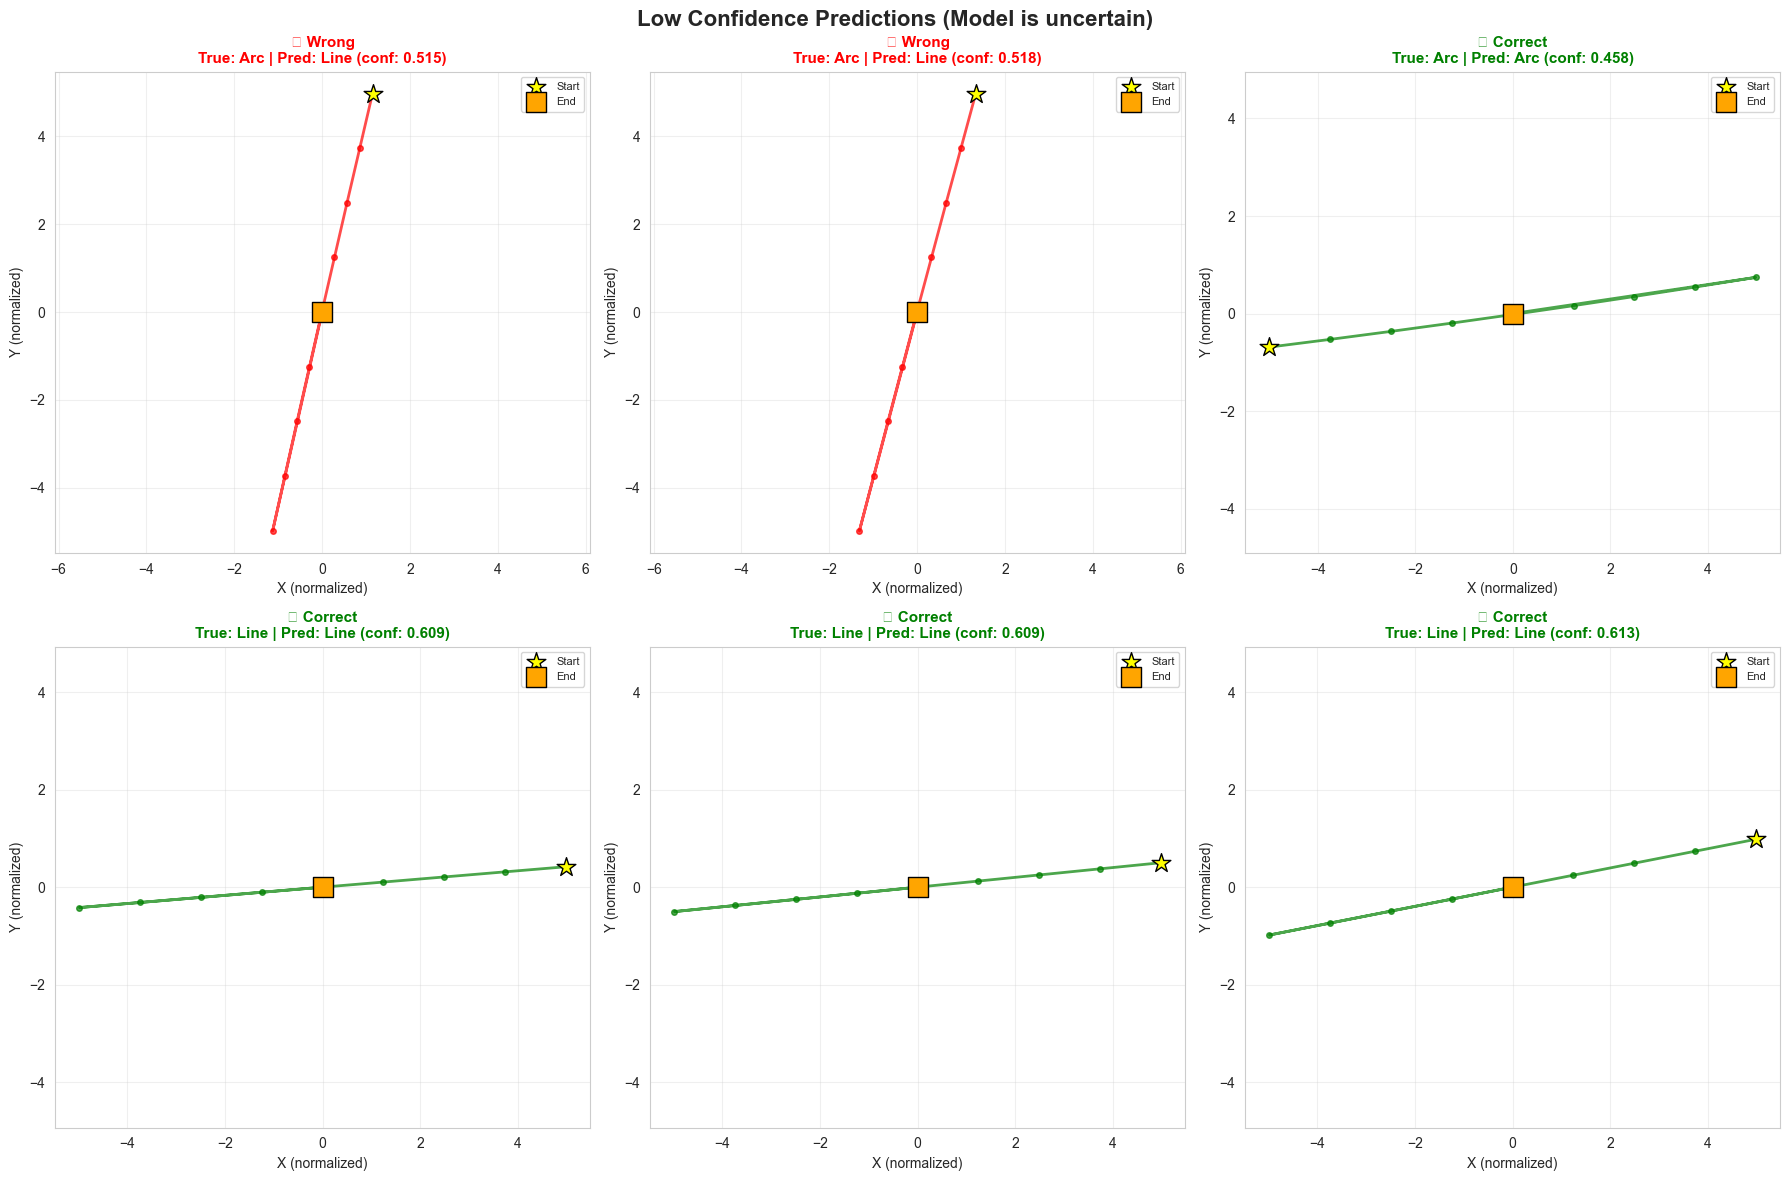

In [11]:
# Find high confidence predictions
confidence_scores = np.abs(y_pred_proba.flatten() - 0.5)  # Distance from decision boundary
high_conf_indices = np.argsort(confidence_scores)[-6:]  # Top 6 most confident

print("High Confidence Predictions (Very certain):")
plot_trajectory_predictions(X_test, y_test, y_pred, y_pred_proba, 
                           high_conf_indices, 
                           title="High Confidence Predictions (Model is very certain)")

# Find low confidence predictions (close to 0.5)
low_conf_indices = np.argsort(confidence_scores)[:6]  # 6 least confident

print("\nLow Confidence Predictions (Uncertain cases):")
plot_trajectory_predictions(X_test, y_test, y_pred, y_pred_proba, 
                           low_conf_indices, 
                           title="Low Confidence Predictions (Model is uncertain)")


## 7. Class-Specific Examples


Arc Examples (Correctly Classified):


/var/folders/_g/nlrpl_cd5mz07kz6t_shzl9w0000gn/T/ipykernel_43402/123718296.py:49: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()


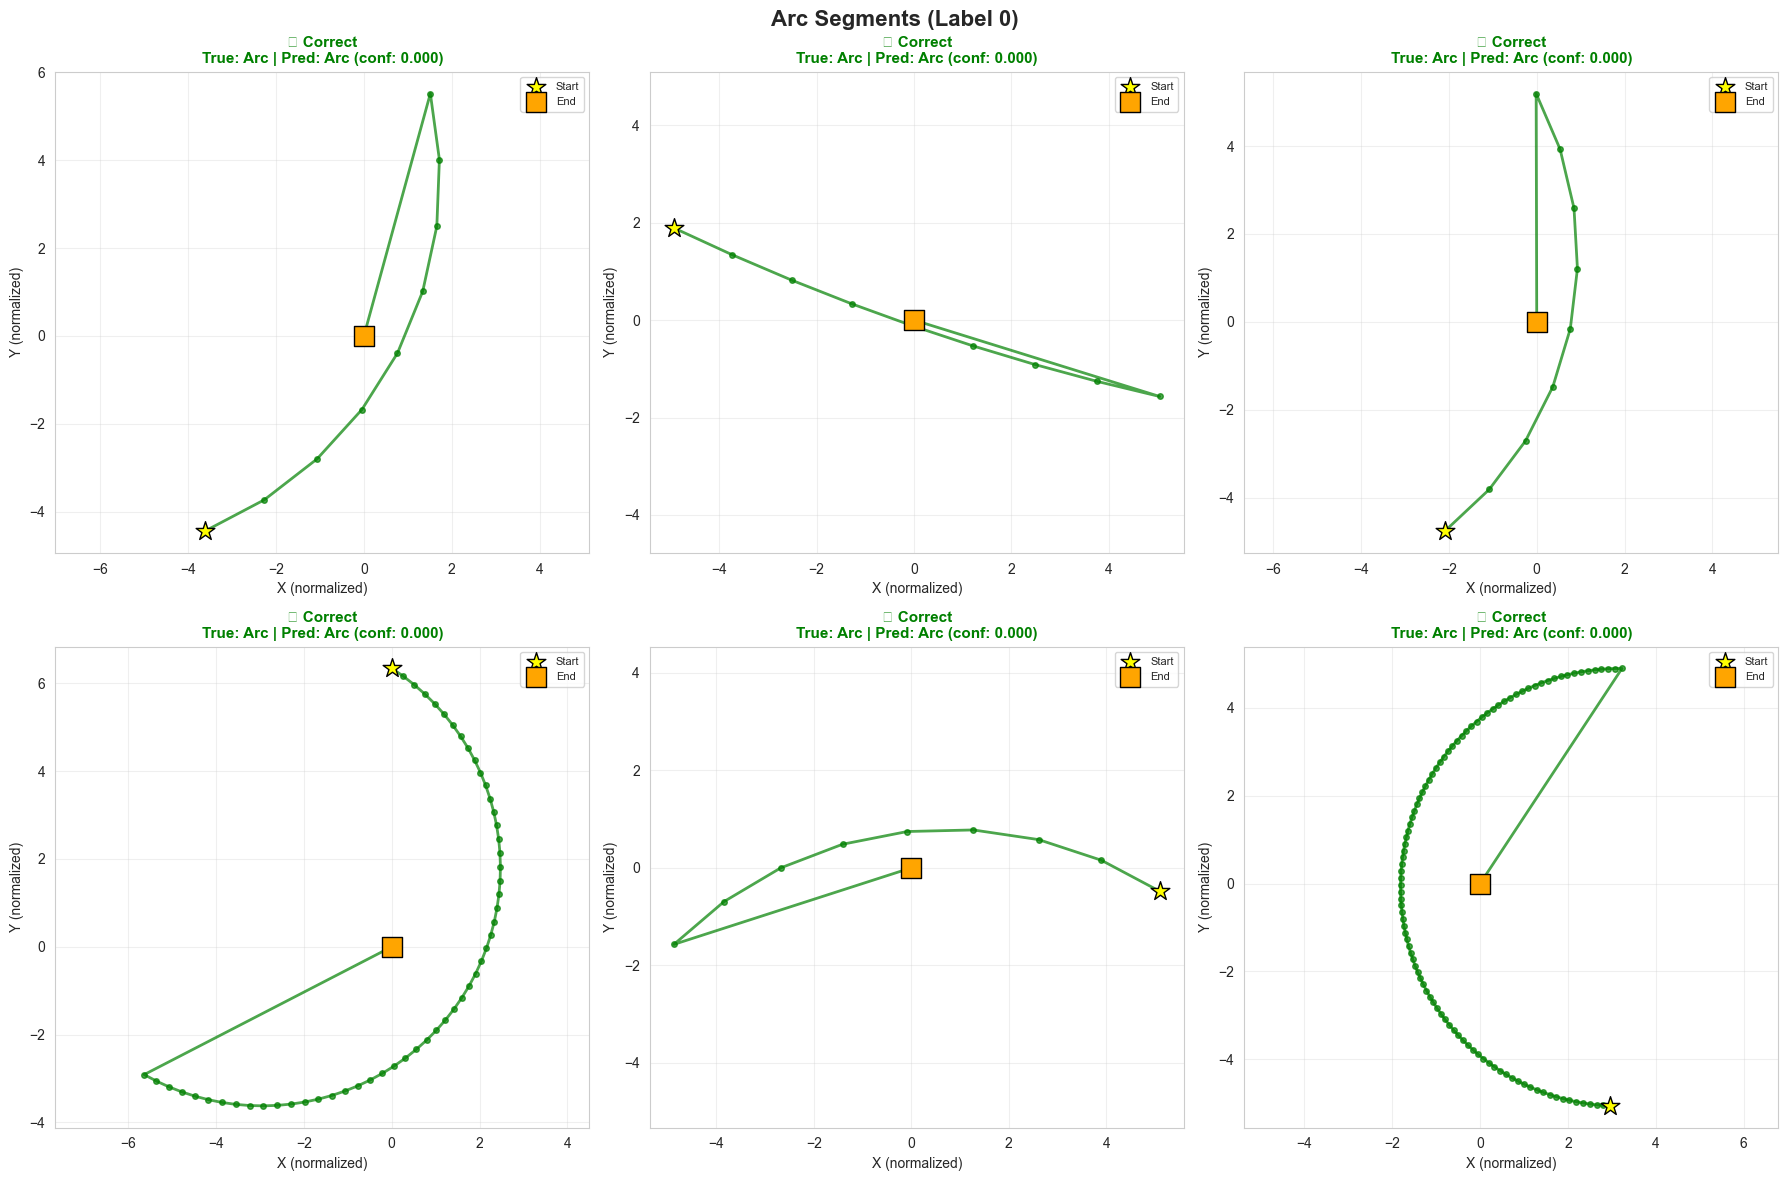


Line Examples (Correctly Classified):


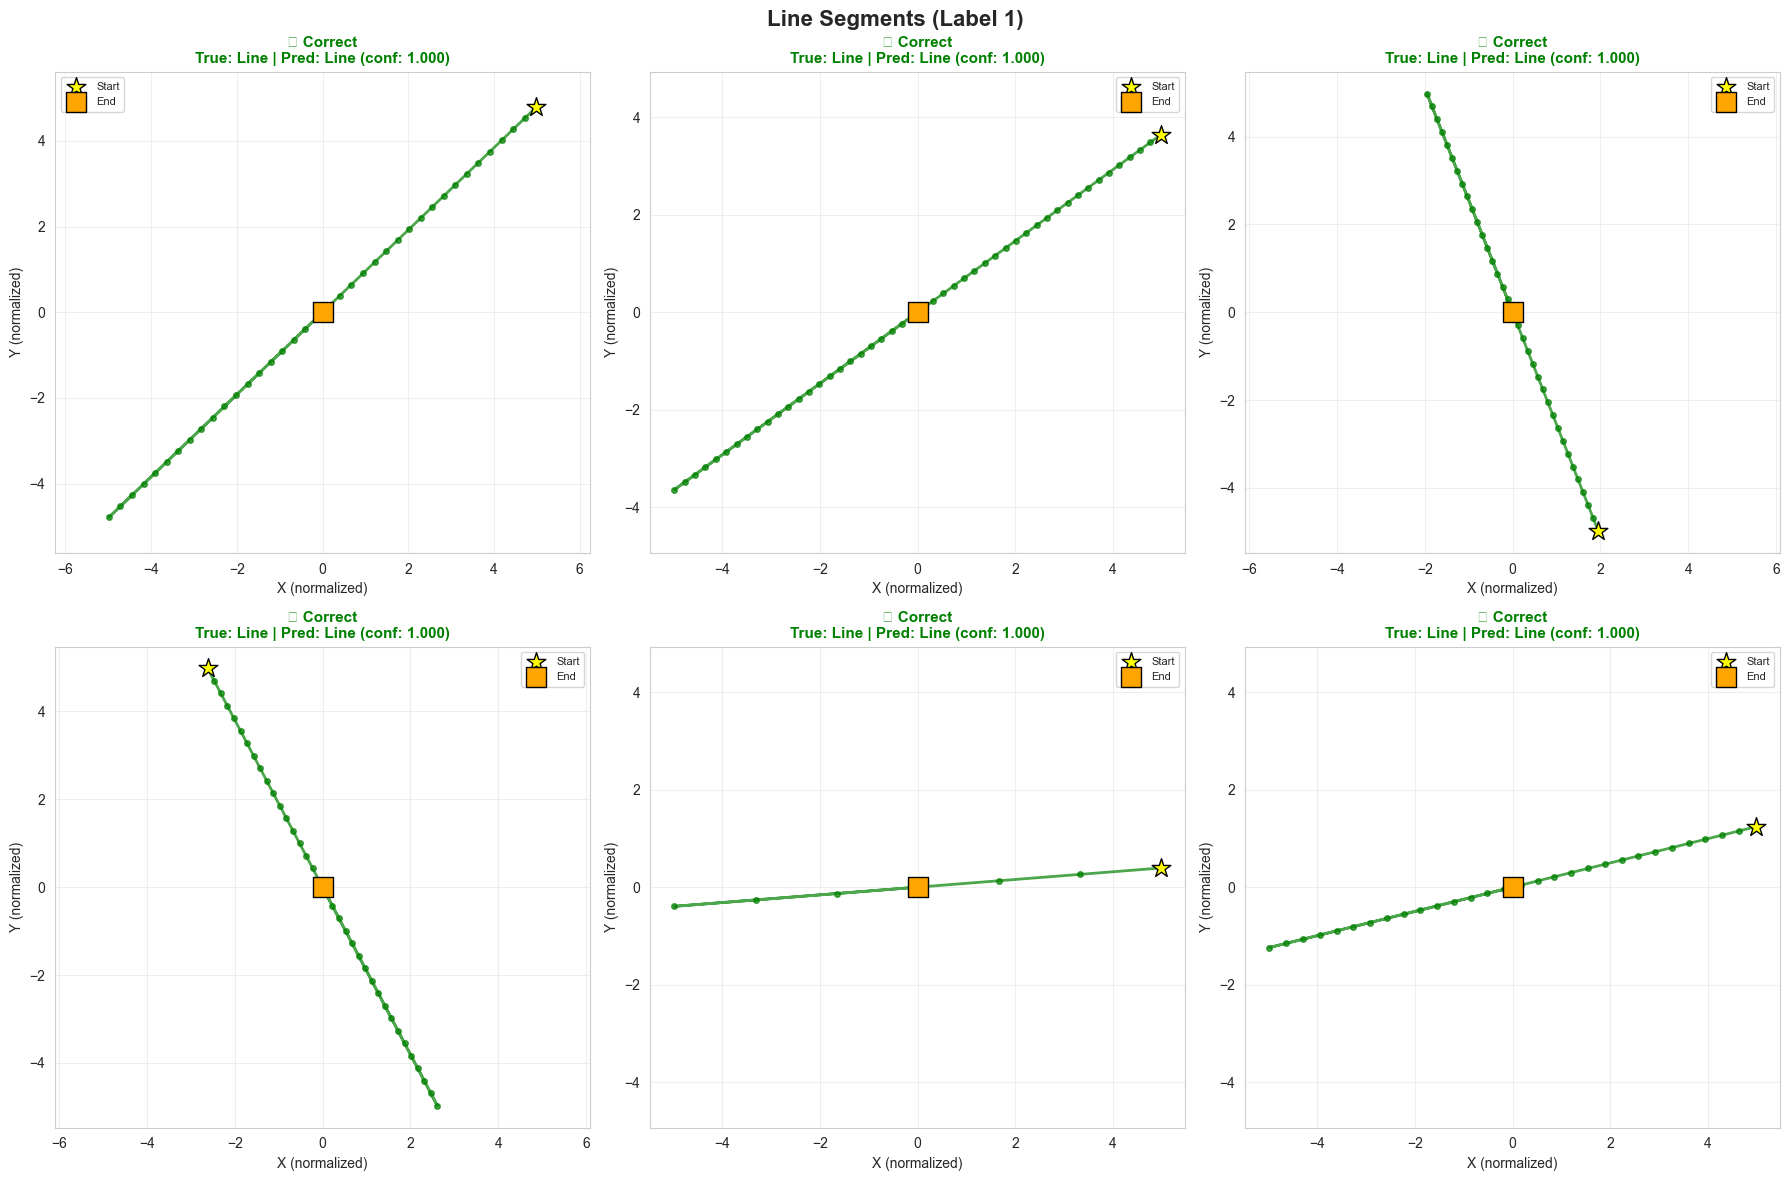

In [12]:
# Show examples of each class
arc_indices = np.where((y_test == 0) & correct_mask)[0]
line_indices = np.where((y_test == 1) & correct_mask)[0]

# Random arcs
print("Arc Examples (Correctly Classified):")
random_arcs = np.random.choice(arc_indices, min(6, len(arc_indices)), replace=False)
plot_trajectory_predictions(X_test, y_test, y_pred, y_pred_proba, 
                           random_arcs, 
                           title="Arc Segments (Label 0)")

# Random lines
print("\nLine Examples (Correctly Classified):")
random_lines = np.random.choice(line_indices, min(6, len(line_indices)), replace=False)
plot_trajectory_predictions(X_test, y_test, y_pred, y_pred_proba, 
                           random_lines, 
                           title="Line Segments (Label 1)")


## 8. Summary Statistics


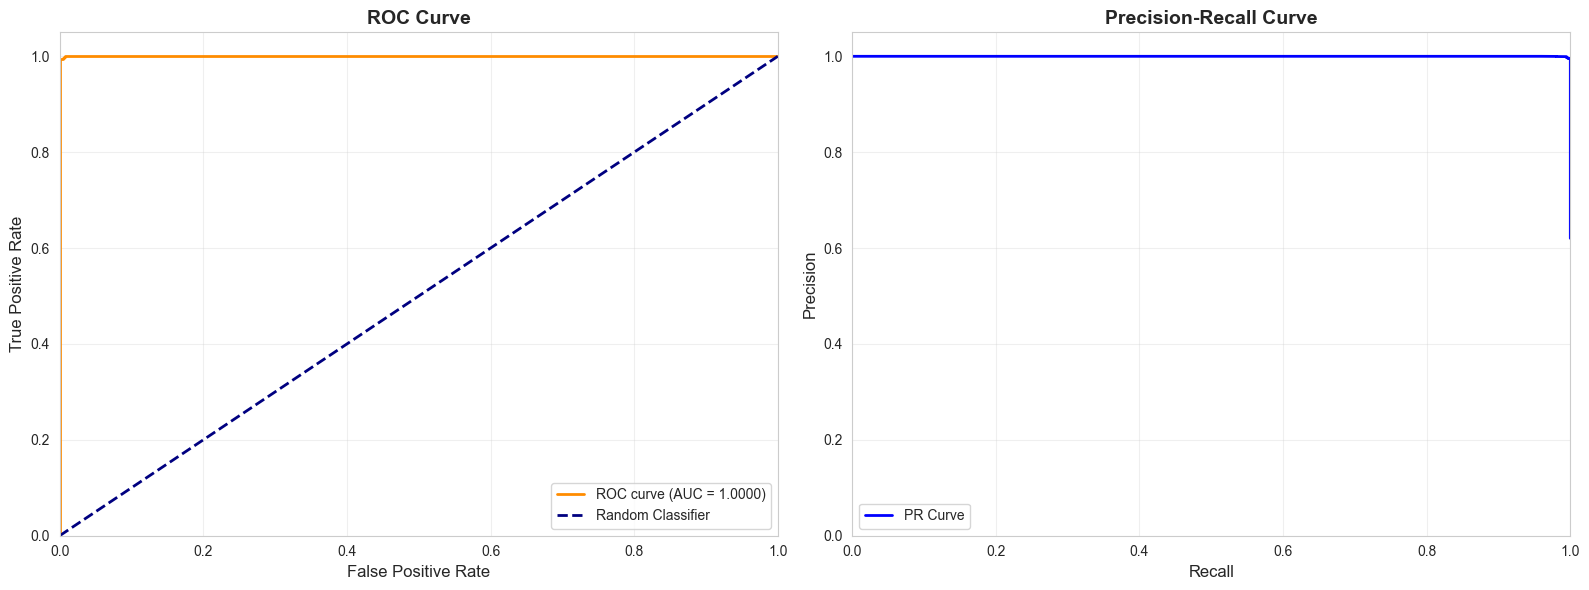


FINAL MODEL PERFORMANCE SUMMARY
Test Samples: 7247
  - Arcs (0): 2752
  - Lines (1): 4495

Accuracy: 0.9967 (99.67%)
ROC-AUC: 0.999950
Correct: 7223 | Incorrect: 24

Model achieves near-perfect classification! 🎉


In [13]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Precision-Recall Curve
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, y_pred_proba)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curve
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curve
axes[1].plot(recall_curve, precision_curve, color='blue', lw=2, label=f'PR Curve')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[1].legend(loc="lower left")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("="*70)
print(f"Test Samples: {len(y_test)}")
print(f"  - Arcs (0): {np.sum(y_test == 0)}")
print(f"  - Lines (1): {np.sum(y_test == 1)}")
print(f"\nAccuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"ROC-AUC: {roc_auc:.6f}")
print(f"Correct: {correct_mask.sum()} | Incorrect: {incorrect_mask.sum()}")
print(f"\nModel achieves near-perfect classification! 🎉")
print("="*70)
